# **Spatial Maps for Mornington Peninsula**

**Types of Spatial Maps:**
 - Rainfall
 - Tmax
 - Tmin
 - Heatwave
 - Drought

**Spatial Map Output:**
 - Rainfall: mornington_rainfall_trend_map.png
 - Tmax: mornington_tmax_trend_maps.png
 - Tmin: mornington_tmin_trend_maps.png
 - Heatwaves: mornington_heatwave_trend_maps.png
 - Droughts:mornington_drought_trend_maps.png

In [2]:
# Setup, Imports, Load Gridded Data (Run Once)

import os
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import pymannkendall as mk

try: 
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature
    HAVE_CARTOPY = True
except ImportError:
    HAVE_CARTOPY = False

base_path = '/g/data/zv2/agcd/v1-0-4'
lat_min, lat_max = -38.50, -38.05
lon_min, lon_max = 144.68, 145.35

CACHE_DIR = '/scratch/ob22/ft3359/mornington_cache'

def load_box(var_subpath, var_name):
    def _preprocess(ds):
        return ds[[var_name]].sel(lat=slice(lat_min, lat_max), lon=slice(lon_min, lon_max))

    ds = xr.open_mfdataset(
        f'{base_path}/{var_subpath}/*.nc',
        combine='by_coords',
        preprocess=_preprocess,
        chunks={'time': 365},
    )
    da = ds[var_name]
    return da.load()

precip_grid = load_box('precip/total/r005/01day', 'precip')
tmax_grid = load_box('tmax/mean/r005/01day', 'tmax')
tmin_grid = load_box('tmin/mean/r005/01day', 'tmin')

print(f"Grid Shape: lat={precip_grid.lat.size}, lon={precip_grid.lon.size}, "
      f"time={precip_grid.time.size}")

# Build Ocean Mask
def build_land_mask_from_data(daily_grid, valid_fraction_threshold=0.5):
    valid_fraction = daily_grid.notnull().mean(dim='time')
    return valid_fraction >= valid_fraction_threshold

LAND_MASK = build_land_mask_from_data(precip_grid)

print(f"Land Mask: {int(LAND_MASK.sum())} of {LAND_MASK.size} gridcells classified as land")

precip_grid = precip_grid.where(LAND_MASK)
tmax_grid = tmax_grid.where(LAND_MASK)
tmin_grid = tmin_grid.where(LAND_MASK)

valid_frac = precip_grid.notnull().mean(dim='time')
print(valid_frac.values)

os.makedirs(CACHE_DIR, exist_ok=True)

precip_grid.to_netcdf(f'{CACHE_DIR}/precip_gird_masked.nc')
tmax_grid.to_netcdf(f'{CACHE_DIR}/tmax_grid_masked.nc')
tmin_grid.to_netcdf(f'{CACHE_DIR}/tmin_grid_masked.nc')
LAND_MASK.to_netcdf(f'{CACHE_DIR}/land_mask.nc')

print(f"Saved cached grids to {CACHE_DIR}")

Grid Shape: lat=10, lon=14, time=46021
Land Mask: 140 of 140 gridcells classified as land
[[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]]
Saved cached grids to /scratch/ob22/ft3359/mornington_cache


In [5]:
# Setup, Imports, Load Cached Gridded Data (Fast)

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import pymannkendall as mk

try: 
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature
    HAVE_CARTOPY = True
except ImportError:
    HAVE_CARTOPY = False

lat_min, lat_max = -38.50, -38.05
lon_min, lon_max = 144.68, 145.35

CACHE_DIR = '/scratch/ob22/ft3359/mornington_cache'

precip_grid = xr.open_dataarray(f'{CACHE_DIR}/precip_gird_masked.nc').load()
tmax_grid = xr.open_dataarray(f'{CACHE_DIR}/tmax_grid_masked.nc').load()
tmin_grid = xr.open_dataarray(f'{CACHE_DIR}/tmin_grid_masked.nc').load()
LAND_MASK = xr.open_dataarray(f'{CACHE_DIR}/land_mask.nc').load()

print(f"Loaded cached grids: lat={precip_grid.lat.size}, lon={precip_grid.lon.size}",
      f"time={precip_grid.time.size}")

Loaded cached grids: lat=10, lon=14 time=46021


In [6]:
# Shared Helper Functions (trend test + Plotting)

def gridded_mk_trend(annual_da, min_years=10):
    """Apply MK/Sen's slope trend test at every grid cell.
    annual_da must have dims (time, lat, lon), loaded into memory."""
    def _mk_pixel(values_1d):
        mask = ~np.isnan(values_1d)
        if mask.sum() < min_years:
            return np.nan, np.nan, np.nan
        try:
            result = mk.original_test(values_1d[mask])
        except Exception:
            return np.nan, np.nan, np.nan
        return result.slope * 10, result.p, result.z  # slope -> per decade

    slope, pval, zval = xr.apply_ufunc(
        _mk_pixel, annual_da,
        input_core_dims=[['time']],
        output_core_dims=[[], [], []],
        vectorize=True,
        output_dtypes=[float, float, float],
    )
    return xr.Dataset({'sen_slope_per_decade': slope, 'p_value': pval, 'z': zval})

def plot_trend_map(trend_ds, title, cbar_label, cmap='RdBu_r', ax=None, symmetric=True):
    slope = trend_ds['sen_slope_per_decade']
    pval = trend_ds['p_value']
    fig = ax.figure

    if symmetric:
        vmax = np.nanmax(np.abs(slope.values))
        vmin = -vmax
    else:
        vmin, vmax = np.nanmin(slope.values), np.nanmax(slope.values)

    if HAVE_CARTOPY:
        mesh = ax.pcolormesh(slope.lon, slope.lat, slope, cmap=cmap, vmin=vmin, vmax=vmax,
                              transform=ccrs.PlateCarree(), shading='auto')
        ax.add_feature(cfeature.COASTLINE.with_scale('10m'), linewidth=0.8)
        ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
        gl = ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5)
        gl.top_labels = False
        gl.right_labels = False
    else:
        mesh = ax.pcolormesh(slope.lon, slope.lat, slope, cmap=cmap, vmin=vmin, vmax=vmax, shading='auto')
        ax.set_xlabel('Longitude')
        ax.set_ylabel('Latitude')

    sig_mask = pval.values < 0.05
    lon2d, lat2d = np.meshgrid(slope.lon.values, slope.lat.values)
    scatter_kwargs = dict(s=8, color='black', marker='.')
    if HAVE_CARTOPY:
        ax.scatter(lon2d[sig_mask], lat2d[sig_mask], transform=ccrs.PlateCarree(), **scatter_kwargs)
    else:
        ax.scatter(lon2d[sig_mask], lat2d[sig_mask], **scatter_kwargs)

    cbar = fig.colorbar(mesh, ax=ax, orientation='vertical', shrink=0.7, extend='both')
    cbar.set_label(cbar_label)
    ax.set_title(title)

def make_subplot_fig(nrows, ncols, figsize):
    subplot_kw = {'projection': ccrs.PlateCarree()} if HAVE_CARTOPY else {}
    return plt.subplots(nrows, ncols, figsize=figsize, subplot_kw=subplot_kw)

Saved: mornington_rainfall_trend_map.png


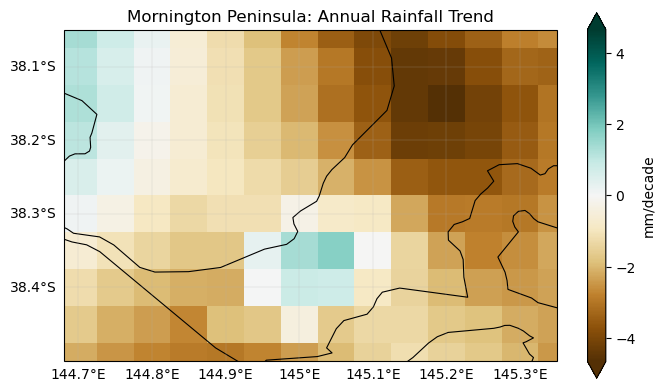

In [7]:
# Rainfall Trend Map

precip_annual_grid = precip_grid.resample(time='YS').sum(skipna=True)
precip_trend_grid = gridded_mk_trend(precip_annual_grid)

fig, ax = make_subplot_fig(1, 1, figsize=(7, 6))
plot_trend_map(precip_trend_grid, 'Mornington Peninsula: Annual Rainfall Trend', 'mm/decade', cmap='BrBG', ax=ax)

fig.tight_layout(rect=[0, 0, 1, 0.92])
fig.savefig('mornington_rainfall_trend_map.png', dpi=200)
print("Saved: mornington_rainfall_trend_map.png")

Saved: mornington_tmax_trend_maps.png


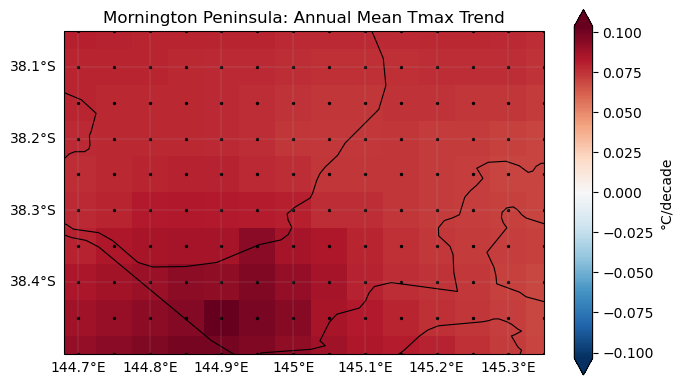

In [8]:
# Tmax Trend Map (annual mean Tmax)
tmax_annual_mean_grid = tmax_grid.resample(time='YS').mean(skipna=True)
tmax_trend_grid = gridded_mk_trend(tmax_annual_mean_grid)

fig, ax = make_subplot_fig(1, 1, figsize=(7, 6))
plot_trend_map(tmax_trend_grid, 'Mornington Peninsula: Annual Mean Tmax Trend', '°C/decade', cmap='RdBu_r', ax=ax)

fig.tight_layout(rect=[0, 0, 1, 0.92])
fig.savefig('mornington_tmax_trend_maps.png', dpi=200)
print("Saved: mornington_tmax_trend_maps.png")

Saved: mornington_tmin_trend_maps.png


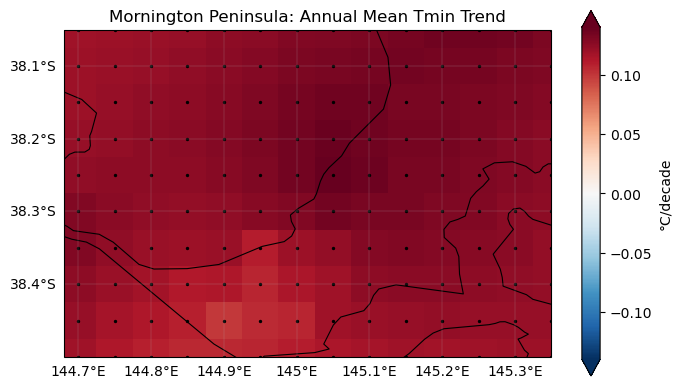

In [9]:
# Tmin Trend Map (annual mean Tmin)
tmin_annual_mean_grid = tmin_grid.resample(time='YS').mean(skipna=True)
tmin_trend_grid = gridded_mk_trend(tmin_annual_mean_grid)

fig, ax = make_subplot_fig(1, 1, figsize=(7, 6))
plot_trend_map(tmin_trend_grid, 'Mornington Peninsula: Annual Mean Tmin Trend', '°C/decade', cmap='RdBu_r', ax=ax)

fig.tight_layout(rect=[0, 0, 1, 0.92])
fig.savefig('mornington_tmin_trend_maps.png', dpi=200)
print("Saved: mornington_tmin_trend_maps.png")

In [10]:
# Days-Over-Threshold Trend Helper Function

def gridded_days_over_trend(daily_grid, threshold, min_years=10):
    # Annual count of days exceeding a temperature threshold
    exceed = (daily_grid > threshold).astype(float)
    annual_counts = exceed.resample(time='YS').sum(skipna=True)
    return gridded_mk_trend(annual_counts, min_years=min_years)

Saved: mornington_tmax_days_over_threshold_map.png


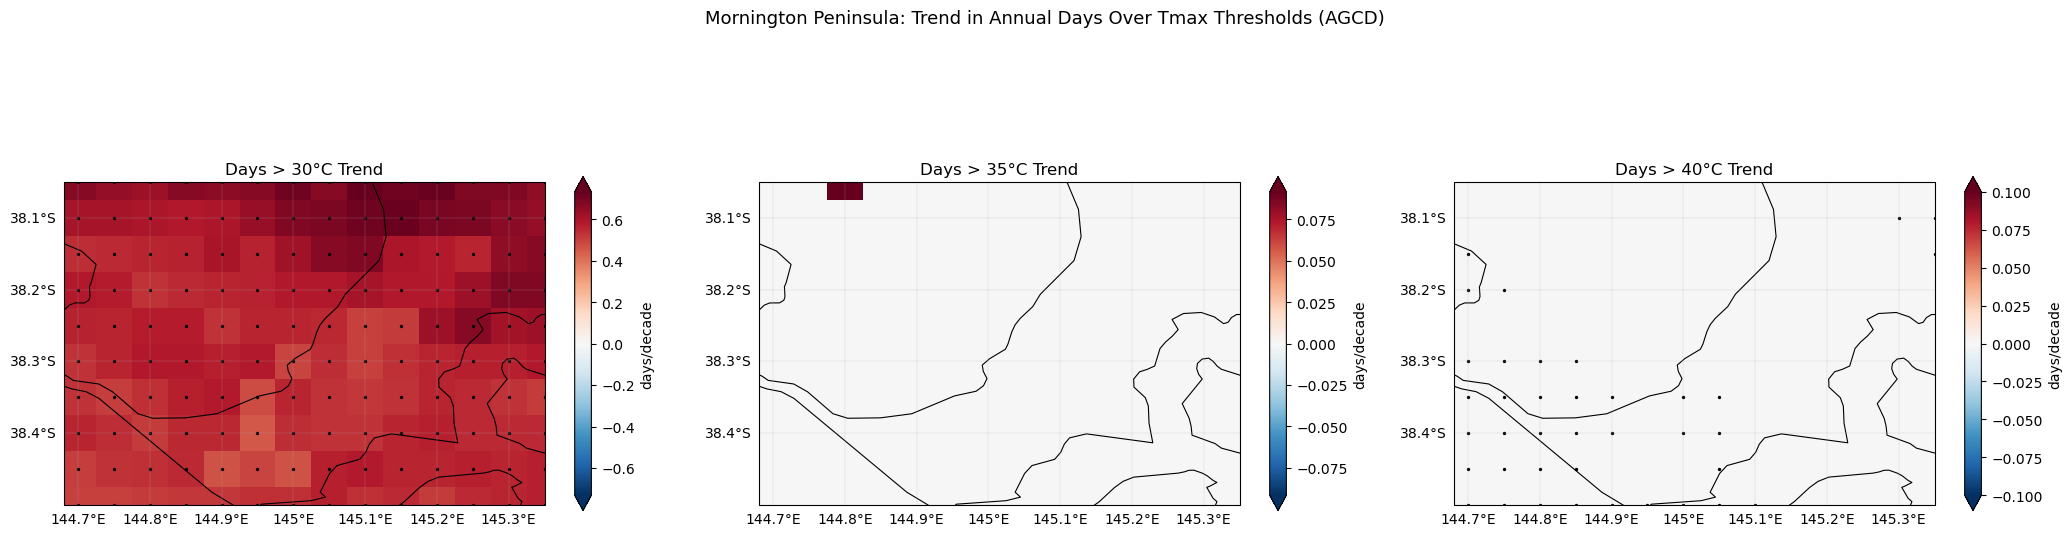

In [11]:
# Tmax Days-Over-Threshold Trend Map

TMAX_THRESHOLDS = [30, 35, 40]

fig, axes = make_subplot_fig(1, len(TMAX_THRESHOLDS), figsize=(7 * len(TMAX_THRESHOLDS), 6))
for ax, threshold in zip(np.atleast_1d(axes), TMAX_THRESHOLDS):
    trend_ds = gridded_days_over_trend(tmax_grid, threshold)
    plot_trend_map(trend_ds, f'Days > {threshold}°C Trend', 'days/decade', cmap='RdBu_r', ax=ax)

fig.suptitle('Mornington Peninsula: Trend in Annual Days Over Tmax Thresholds (AGCD)', fontsize=13)
fig.tight_layout(rect=[0, 0, 1, 0.90])
fig.savefig('mornington_tmax_days_over_threshold_map.png', dpi=200)
print("Saved: mornington_tmax_days_over_threshold_map.png")

Saved: mornington_tmin_days_over_threshold_map.png


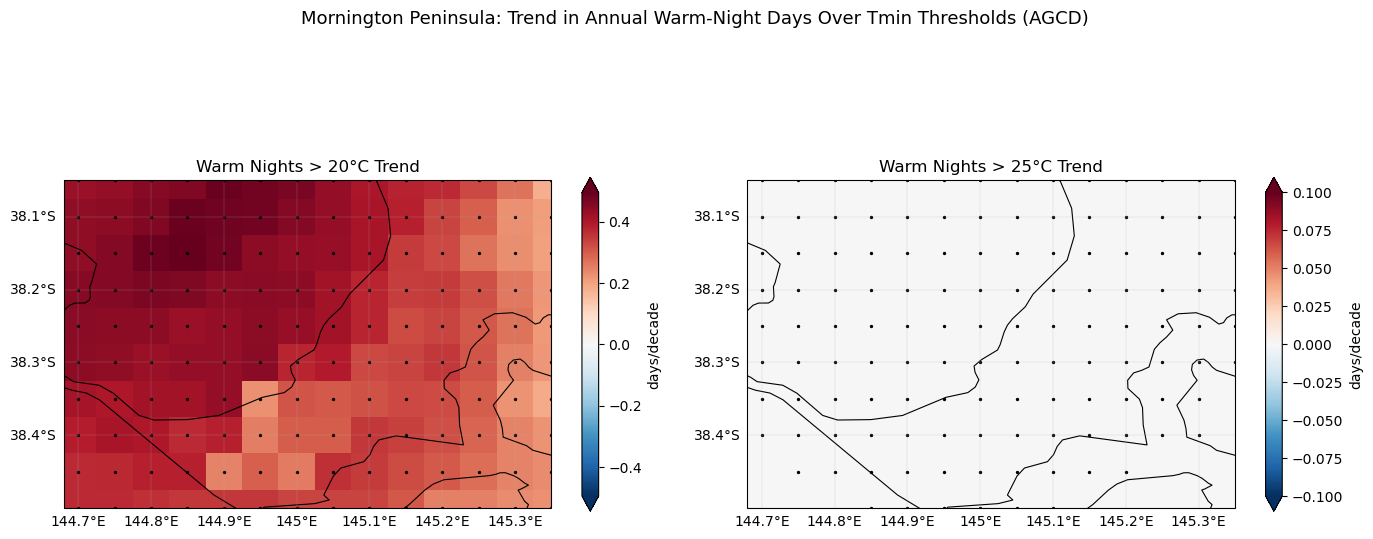

In [12]:
# Tmin Warm-Night Threshold Trend Map

TMIN_THRESHOLDS = [20, 25]

fig, axes = make_subplot_fig(1, len(TMIN_THRESHOLDS), figsize=(7 * len(TMIN_THRESHOLDS), 6))
for ax, threshold in zip(np.atleast_1d(axes), TMIN_THRESHOLDS):
    trend_ds = gridded_days_over_trend(tmin_grid, threshold)
    plot_trend_map(trend_ds, f'Warm Nights > {threshold}°C Trend', 'days/decade', cmap='RdBu_r', ax=ax)

fig.suptitle('Mornington Peninsula: Trend in Annual Warm-Night Days Over Tmin Thresholds (AGCD)', fontsize=13)
fig.tight_layout(rect=[0, 0, 1, 0.90])
fig.savefig('mornington_tmin_days_over_threshold_map.png', dpi=200)
print("Saved: mornington_tmin_days_over_threshold_map.png")

In [13]:
# Raw Occurrance & Spilt-period difference

def gridded_total_occurrence(daily_grid, threshold):
    # Total number of days exceeding threshold across the full record
    exceed = (daily_grid > threshold).astype(float)
    return exceed.sum(dim='time', skipna=True)

def gridded_period_difference(daily_grid, threshold, early_years, recent_years):
    # Mean Annual Exceedance days: recent period minus early period
    exceed = (daily_grid > threshold).astype(float)
    annual_counts = exceed.resample(time='YS').sum(skipna=True)
    early = annual_counts.sel(time=slice(f'{early_years[0]}-01-01', f'{early_years[1]}-12-31')).mean(dim='time')
    recent = annual_counts.sel(time=slice(f'{recent_years[0]}-01-01', f'{recent_years[1]}-12-31')).mean(dim='time')
    return recent - early

def gridded_period_percent_difference(daily_grid, threshold, early_years, recent_years, min_early_days=0.1):
    # Percentage change in mean annual exceedance days, recent vs early period
    exceed = (daily_grid > threshold).astype(float)
    annual_counts = exceed.resample(time='YS').sum(skipna=True)
    early = annual_counts.sel(time=slice(f'{early_years[0]}-01-01', f'{early_years[1]}-12-31')).mean(dim='time')
    recent = annual_counts.sel(time=slice(f'{recent_years[0]}-01-01', f'{recent_years[1]}-12-31')).mean(dim='time')
    pct_change = 100 * (recent - early) / early
    pct_change = pct_change.where(early >= min_early_days)
    return pct_change

Saved: mornington_tmax_extreme_change_percent.png


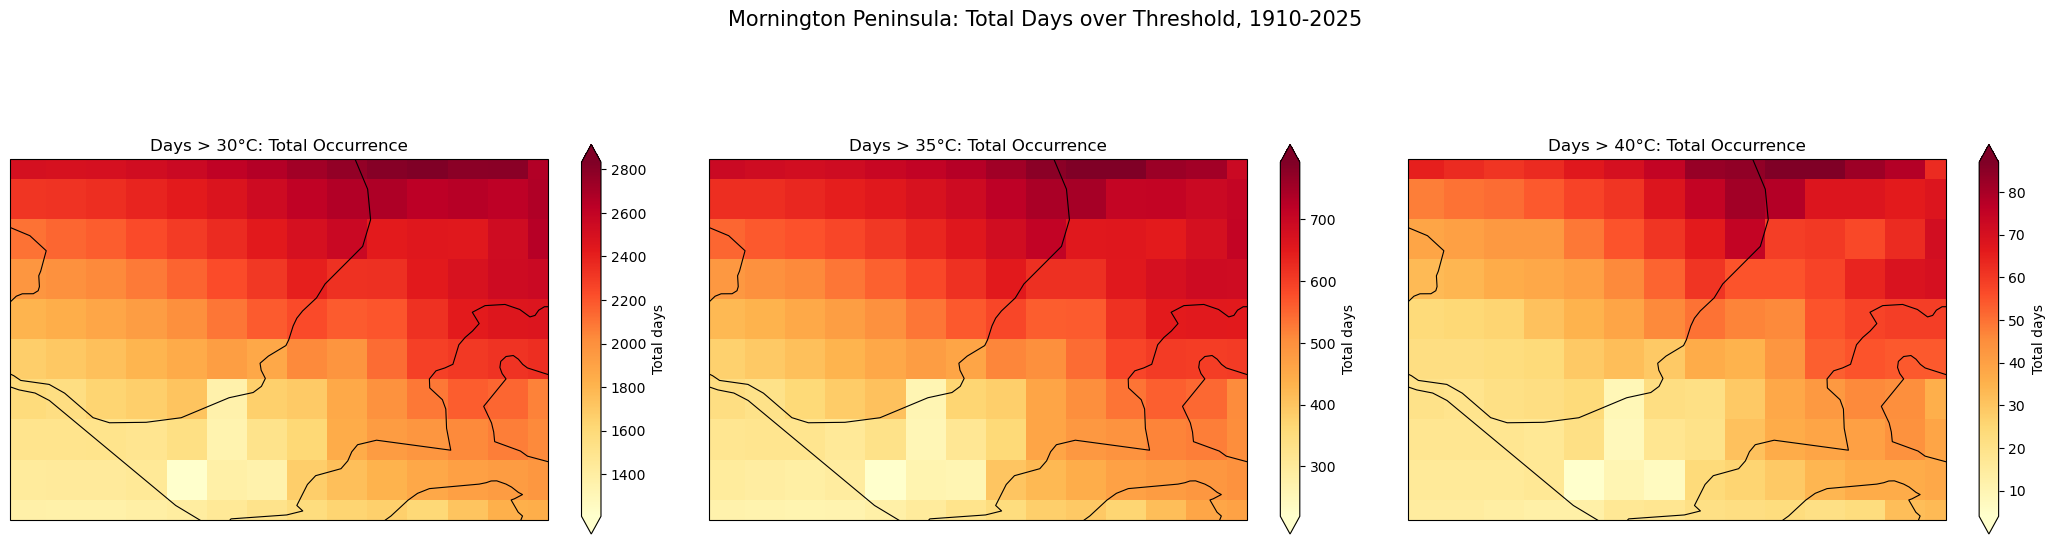

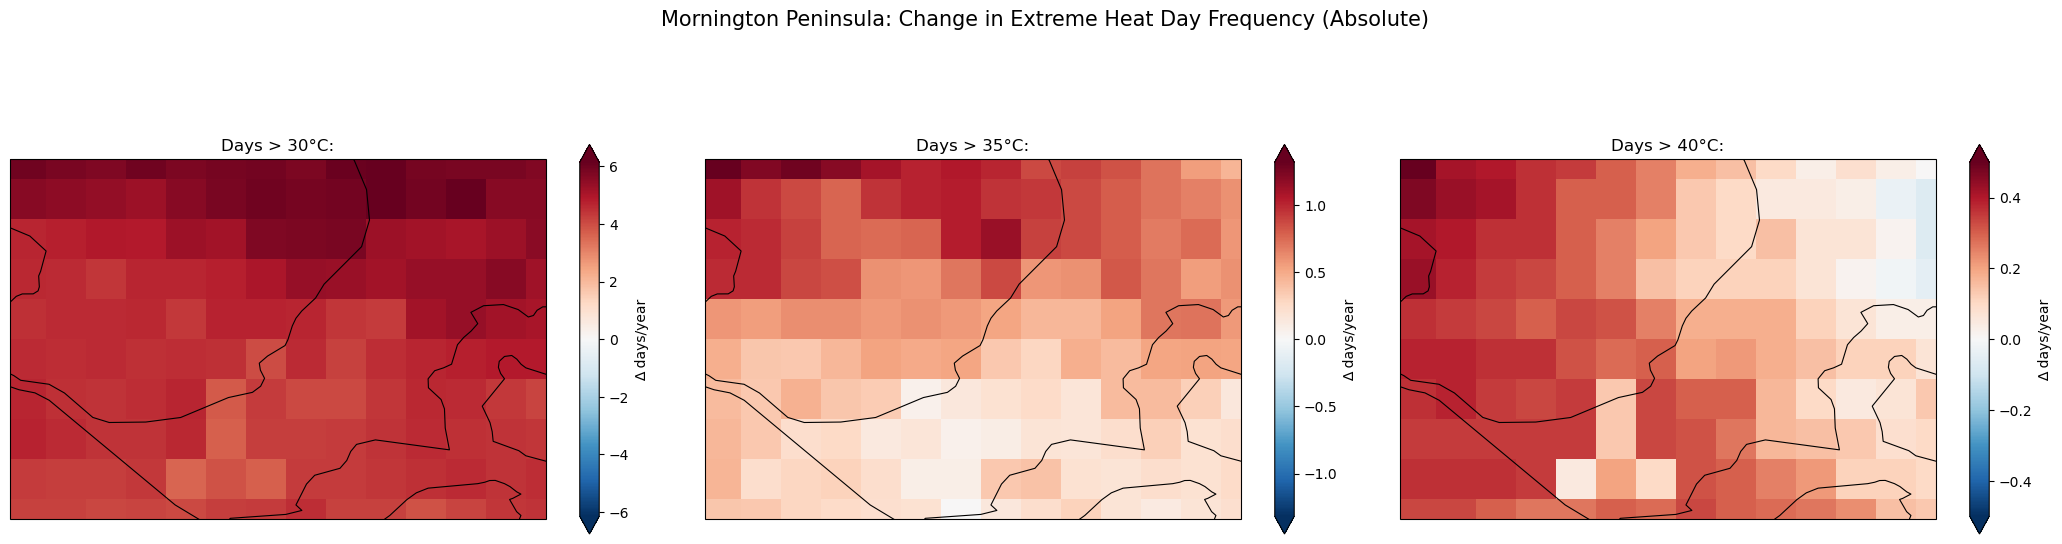

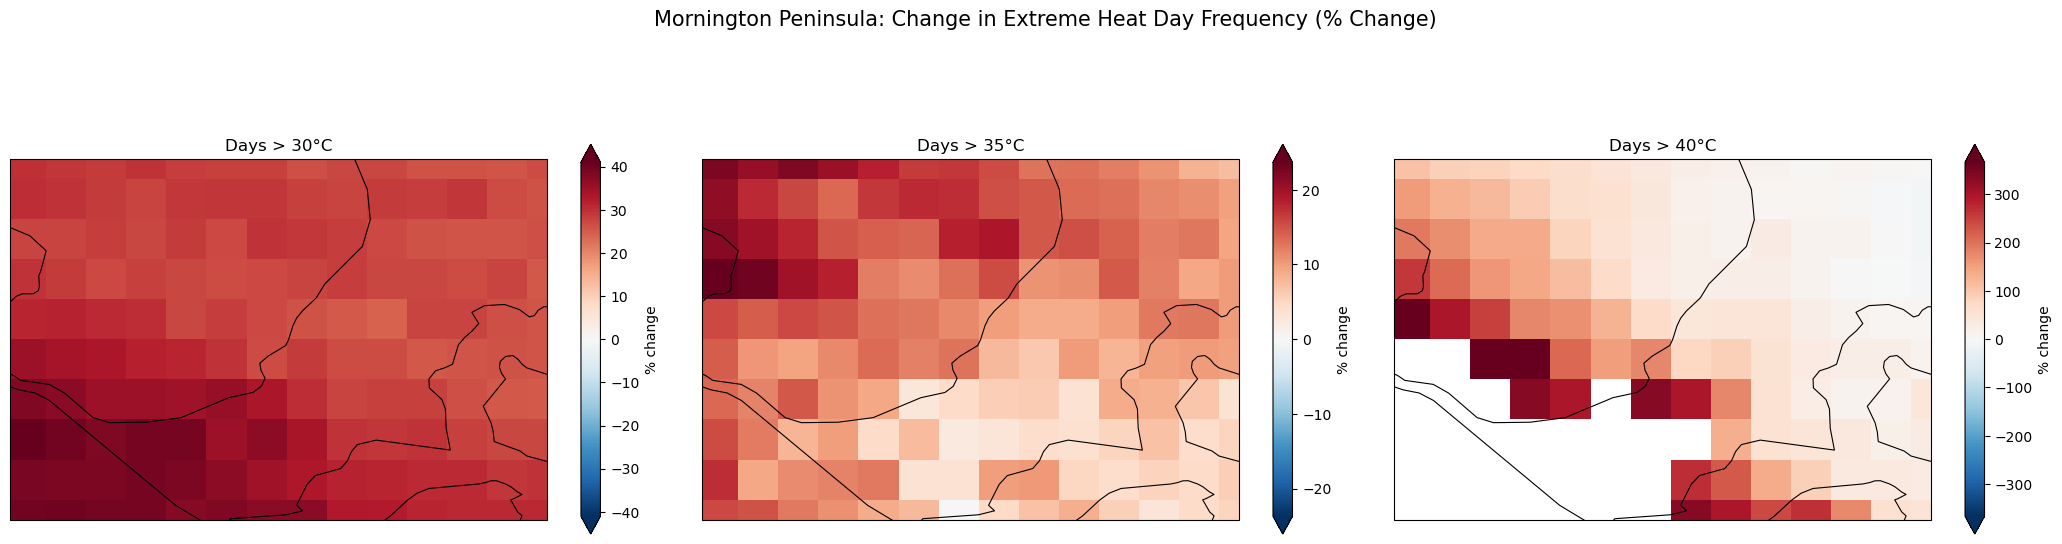

In [14]:
# Plot Raw Occurrance Map

fig, axes = make_subplot_fig(1, 3, figsize=(21, 6))
for ax, threshold in zip(np.atleast_1d(axes), [30, 35, 40]):
    total = gridded_total_occurrence(tmax_grid, threshold)
    mesh = ax.pcolormesh(total.lon, total.lat, total, cmap='YlOrRd', shading='auto', transform=ccrs.PlateCarree() if HAVE_CARTOPY else None)

    if HAVE_CARTOPY:
        ax.add_feature(cfeature.COASTLINE.with_scale('10m'), linewidth=0.8)
        ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
    fig.colorbar(mesh, ax=ax, shrink=0.8, label='Total days', extend='both')
    ax.set_title(f'Days > {threshold}°C: Total Occurrence')

fig.suptitle('Mornington Peninsula: Total Days over Threshold, 1910-2025', fontsize=15)
fig.tight_layout(rect=[0, 0, 1, 0.92])

# Plot Split-period Difference Map

fig, axes = make_subplot_fig(1, 3, figsize=(21, 6))
for ax, threshold in zip(np.atleast_1d(axes), [30, 35, 40]):
    diff = gridded_period_difference(tmax_grid, threshold, (1910, 1969), (1996, 2025))
    vmax = np.nanmax(np.abs(diff.values))
    mesh = ax.pcolormesh(diff.lon, diff.lat, diff, cmap='RdBu_r', vmin=-vmax, vmax=vmax, shading='auto', transform=ccrs.PlateCarree() if HAVE_CARTOPY else None)

    if HAVE_CARTOPY:
        ax.add_feature(cfeature.COASTLINE.with_scale('10m'), linewidth=0.8)
        ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
    fig.colorbar(mesh, ax=ax, shrink=0.8, label='∆ days/year', extend='both')
    ax.set_title(f'Days > {threshold}°C:')

fig.suptitle('Mornington Peninsula: Change in Extreme Heat Day Frequency (Absolute)', fontsize=15)
fig.tight_layout(rect=[0, 0, 1, 0.92])

# Plot Split-period Difference Map (Percentage Change)

fig, axes = make_subplot_fig(1, 3, figsize=(21, 6))
for ax, threshold in zip(np.atleast_1d(axes), [30, 35, 40]):
    pct_diff = gridded_period_percent_difference(tmax_grid, threshold, (1910, 1969), (1996, 2025))
    vmax = np.nanmax(np.abs(pct_diff.values)) if np.any(~np.isnan(pct_diff.values)) else 100
    mesh = ax.pcolormesh(pct_diff.lon, pct_diff.lat, pct_diff, cmap='RdBu_r', vmin=-vmax, vmax=vmax, shading='auto', transform=ccrs.PlateCarree() if HAVE_CARTOPY else None)

    if HAVE_CARTOPY: 
        ax.add_feature(cfeature.COASTLINE.with_scale('10m'), linewidth=0.8)
        ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
    fig.colorbar(mesh, ax=ax, shrink=0.8, label='% change', extend='both')
    ax.set_title(f'Days > {threshold}°C')
fig.suptitle('Mornington Peninsula: Change in Extreme Heat Day Frequency (% Change)', fontsize=15)
fig.tight_layout(rect=[0, 0, 1, 0.92])
fig.savefig('mornington_tmax_extreme_change_percent.png', dpi=200)
print("Saved: mornington_tmax_extreme_change_percent.png")

Running per-pixel heatwave trend analysis over 10x14 grid cells...
  row 1/10 done
  row 2/10 done
  row 3/10 done
  row 4/10 done
  row 5/10 done
  row 6/10 done
  row 7/10 done
  row 8/10 done
  row 9/10 done
  row 10/10 done
Saved: mornington_heatwave_trend_maps.png


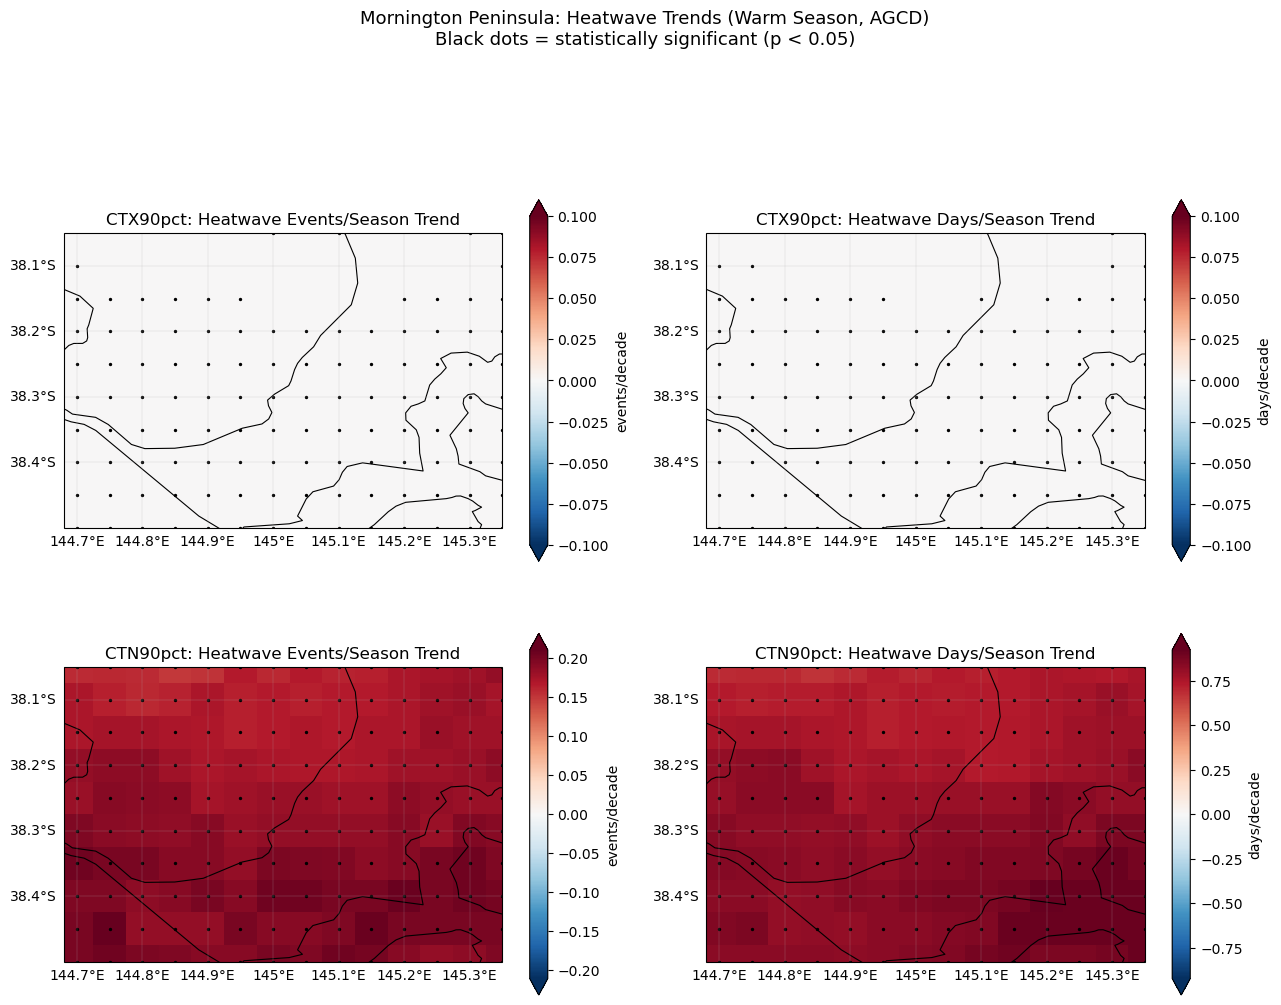

In [15]:
# Heatwave Trend Maps (Warm Season, CTX90pct/CTN90pct, per pixel)

# Matches your box-mean heatwave script's parameters exactly
CLIM_START, CLIM_END = 1961, 1990
DOY_WINDOW = 15
PCTL = 90
MIN_RUN_LENGTH = 3
SEASON_MONTHS = [11, 12, 1, 2, 3]
SEASON_START_MONTH = 11

def build_doy(index):
    doy = index.dayofyear
    shift = (index.is_leap_year) & (doy > 59)
    return np.where(shift, doy - 1, doy)

def calendar_day_percentile(series, clim_start, clim_end, pctl, window):
    avail_start_year = series.index.min().year
    if clim_start < avail_start_year:
        clim_start = avail_start_year
        clim_end = clim_start + 29
    mask = (series.index.year >= clim_start) & (series.index.year <= clim_end)
    ref = series[mask].dropna()
    ref = ref[~((ref.index.month == 2) & (ref.index.day == 29))]
    ref_doy = build_doy(ref.index)
    ref_vals = ref.values
    all_days = np.arange(1, 366)
    diff = np.abs(ref_doy[:, None] - all_days[None, :])
    circ_diff = np.minimum(diff, 365 - diff)
    thresholds = {}
    for i, d in enumerate(all_days):
        vals = ref_vals[circ_diff[:, i] <= window]
        thresholds[d] = np.nanpercentile(vals, pctl) if len(vals) > 0 else np.nan
    full_doy = build_doy(series.index)
    return pd.Series(full_doy, index=series.index).map(thresholds)

def flag_heatwave_days(values, thresholds, min_run):
    exceed = (values > thresholds).astype(int)
    run_id = (exceed != exceed.shift()).cumsum()
    run_length = exceed.groupby(run_id).transform('size') * exceed
    is_hw_day = (exceed == 1) & (run_length >= min_run)
    event_id = np.where(is_hw_day, run_id, np.nan)
    return is_hw_day, event_id

def compute_aspects(season_df, var_col, is_hw_col, event_id_col):
    records = []
    for yr, grp in season_df.groupby('season_year'):
        hw_days = grp[grp[is_hw_col]]
        n_events = hw_days[event_id_col].nunique()
        records.append({'season_year': yr, 'HWN': n_events, 'HWF': len(hw_days)})
    return pd.DataFrame(records).set_index('season_year').sort_index()

def mk_trend_series(series, min_n=8):
    s = series.dropna()
    if len(s) < min_n:
        return np.nan, np.nan
    result = mk.original_test(s.values)
    return result.slope * 10, result.p  # per decade

def pixel_heatwave_trends(tx_1d, tn_1d, time_index):
    """Full CTX90pct/CTN90pct pipeline for one grid cell. Returns 8 values:
    HWN/HWF slope+p for CTX90pct, then HWN/HWF slope+p for CTN90pct."""
    TX = pd.Series(tx_1d, index=time_index).sort_index()
    TN = pd.Series(tn_1d, index=time_index).sort_index()
    TX = TX[~TX.index.duplicated()]
    TN = TN[~TN.index.duplicated()]
    if TX.dropna().empty or TN.dropna().empty:
        return (np.nan,) * 8

    TX90 = calendar_day_percentile(TX, CLIM_START, CLIM_END, PCTL, DOY_WINDOW)
    TN90 = calendar_day_percentile(TN, CLIM_START, CLIM_END, PCTL, DOY_WINDOW)

    tx_is_hw, tx_event_id = flag_heatwave_days(TX, TX90, MIN_RUN_LENGTH)
    tn_is_hw, tn_event_id = flag_heatwave_days(TN, TN90, MIN_RUN_LENGTH)

    df = pd.DataFrame({
        'TX90': TX90, 'TN90': TN90,
        'tx_is_hw': tx_is_hw, 'tx_event_id': tx_event_id,
        'tn_is_hw': tn_is_hw, 'tn_event_id': tn_event_id,
    }).dropna(subset=['TX90', 'TN90'])

    season_df = df[df.index.month.isin(SEASON_MONTHS)].copy()
    if season_df.empty:
        return (np.nan,) * 8
    season_df['season_year'] = np.where(
        season_df.index.month >= SEASON_START_MONTH,
        season_df.index.year, season_df.index.year - 1
    )

    ctx = compute_aspects(season_df, 'TX', 'tx_is_hw', 'tx_event_id')
    ctn = compute_aspects(season_df, 'TN', 'tn_is_hw', 'tn_event_id')
    if len(ctx) > 2:
        ctx = ctx.iloc[1:-1]
    if len(ctn) > 2:
        ctn = ctn.iloc[1:-1]

    ctx_hwn_slope, ctx_hwn_p = mk_trend_series(ctx['HWN'])
    ctx_hwf_slope, ctx_hwf_p = mk_trend_series(ctx['HWF'])
    ctn_hwn_slope, ctn_hwn_p = mk_trend_series(ctn['HWN'])
    ctn_hwf_slope, ctn_hwf_p = mk_trend_series(ctn['HWF'])

    return (ctx_hwn_slope, ctx_hwn_p, ctx_hwf_slope, ctx_hwf_p,
            ctn_hwn_slope, ctn_hwn_p, ctn_hwf_slope, ctn_hwf_p)

# Loop over grid cells (small box -> fast enough without dask)
time_index = pd.to_datetime(tmax_grid['time'].values)
lats, lons = tmax_grid['lat'].values, tmax_grid['lon'].values
n_lat, n_lon = len(lats), len(lons)

out_names = ['ctx_hwn_slope', 'ctx_hwn_p', 'ctx_hwf_slope', 'ctx_hwf_p',
             'ctn_hwn_slope', 'ctn_hwn_p', 'ctn_hwf_slope', 'ctn_hwf_p']
out_grids = {name: np.full((n_lat, n_lon), np.nan) for name in out_names}

print(f"Running per-pixel heatwave trend analysis over {n_lat}x{n_lon} grid cells...")
for i in range(n_lat):
    for j in range(n_lon):
        tx_1d = tmax_grid.isel(lat=i, lon=j).values
        tn_1d = tmin_grid.isel(lat=i, lon=j).values
        results = pixel_heatwave_trends(tx_1d, tn_1d, time_index)
        for name, val in zip(out_names, results):
            out_grids[name][i, j] = val
    print(f"  row {i+1}/{n_lat} done")

def make_trend_ds(slope_key, p_key):
    return xr.Dataset({
        'sen_slope_per_decade': (('lat', 'lon'), out_grids[slope_key]),
        'p_value': (('lat', 'lon'), out_grids[p_key]),
    }, coords={'lat': lats, 'lon': lons})

ctx_hwn_trend_grid = make_trend_ds('ctx_hwn_slope', 'ctx_hwn_p')
ctx_hwf_trend_grid = make_trend_ds('ctx_hwf_slope', 'ctx_hwf_p')
ctn_hwn_trend_grid = make_trend_ds('ctn_hwn_slope', 'ctn_hwn_p')
ctn_hwf_trend_grid = make_trend_ds('ctn_hwf_slope', 'ctn_hwf_p')

fig, axes = make_subplot_fig(2, 2, figsize=(13, 11))
plot_trend_map(ctx_hwn_trend_grid, 'CTX90pct: Heatwave Events/Season Trend', 'events/decade', cmap='RdBu_r', ax=axes[0,0])
plot_trend_map(ctx_hwf_trend_grid, 'CTX90pct: Heatwave Days/Season Trend', 'days/decade', cmap='RdBu_r', ax=axes[0,1])
plot_trend_map(ctn_hwn_trend_grid, 'CTN90pct: Heatwave Events/Season Trend', 'events/decade', cmap='RdBu_r', ax=axes[1,0])
plot_trend_map(ctn_hwf_trend_grid, 'CTN90pct: Heatwave Days/Season Trend', 'days/decade', cmap='RdBu_r', ax=axes[1,1])

fig.suptitle('Mornington Peninsula: Heatwave Trends (Warm Season, AGCD)\n'
             'Black dots = statistically significant (p < 0.05)', fontsize=13)
fig.tight_layout(rect=[0, 0, 1, 0.94])
fig.savefig('mornington_heatwave_trend_maps.png', dpi=200)
print("Saved: mornington_heatwave_trend_maps.png")

Running per-pixel drought trend analysis over 10x14 grid cells...
  row 1/10 done
  row 2/10 done
  row 3/10 done
  row 4/10 done
  row 5/10 done
  row 6/10 done
  row 7/10 done
  row 8/10 done
  row 9/10 done
  row 10/10 done
Saved: mornington_drought_trend_maps.png


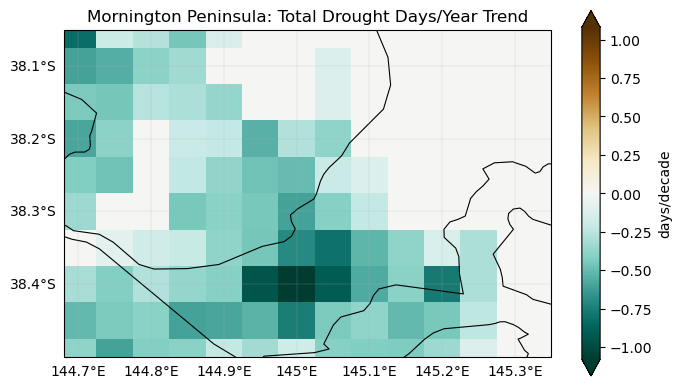

In [16]:
# Drought Trend Map
ROLL_WINDOW_DAYS = 28
MIN_EVENT_LEN_DAYS = 14
DEFICIT_THRESHOLD_PCT = 50

def pixel_drought_trends(precip_1d, time_index):
    s = pd.Series(precip_1d, index=time_index).sort_index()
    da = xr.DataArray(s.values, dims='time', coords={'time': s.index})
    roll_sum = da.rolling(time=ROLL_WINDOW_DAYS, min_periods=ROLL_WINDOW_DAYS).sum()
    doy = roll_sum['time'].dt.dayofyear
    clim = roll_sum.groupby(doy).mean(skipna=True)
    clim_expanded = clim.sel(dayofyear=doy)
    pct_of_normal = 100 * roll_sum / clim_expanded
    df = pd.DataFrame({'time': da['time'].values, 'pct_of_normal': pct_of_normal.values})
    df = df.dropna(subset=['pct_of_normal']).reset_index(drop=True)
    if df.empty:
        return np.nan, np.nan
    df['is_deficit'] = df['pct_of_normal'] < DEFICIT_THRESHOLD_PCT
    df['run_id'] = (df['is_deficit'] != df['is_deficit'].shift()).cumsum()
    events = []
    for run_id, group in df[df['is_deficit']].groupby('run_id'):
        duration = len(group)
        if duration < MIN_EVENT_LEN_DAYS:
            continue
        events.append({'duration_days': duration, 'year': pd.Timestamp(group['time'].iloc[0]).year})
    events_df = pd.DataFrame(events)
    if events_df.empty:
        return np.nan, np.nan
    year_range = np.arange(int(df['time'].min().year), int(df['time'].max().year) + 1)
    annual = pd.DataFrame({'year': year_range})
    annual['total_drought_days'] = annual['year'].map(events_df.groupby('year')['duration_days'].sum()).fillna(0)
    d_slope, d_p = mk_trend_series(annual.set_index('year')['total_drought_days'], min_n=8)
    return d_slope, d_p

time_index = pd.to_datetime(precip_grid['time'].values)
lats, lons = precip_grid['lat'].values, precip_grid['lon'].values
n_lat, n_lon = len(lats), len(lons)

out_names = ['totaldays_slope', 'totaldays_p']
out_grids = {name: np.full((n_lat, n_lon), np.nan) for name in out_names}

print(f"Running per-pixel drought trend analysis over {n_lat}x{n_lon} grid cells...")
for i in range(n_lat):
    for j in range(n_lon):
        precip_1d = precip_grid.isel(lat=i, lon=j).values
        results = pixel_drought_trends(precip_1d, time_index)
        for name, val in zip(out_names, results):
            out_grids[name][i, j] = val
    print(f"  row {i+1}/{n_lat} done")

def make_trend_ds(slope_key, p_key):
    return xr.Dataset({
        'sen_slope_per_decade': (('lat', 'lon'), out_grids[slope_key]),
        'p_value': (('lat', 'lon'), out_grids[p_key]),
    }, coords={'lat': lats, 'lon': lons})

drought_totaldays_trend_grid = make_trend_ds('totaldays_slope', 'totaldays_p')

fig, ax = make_subplot_fig(1, 1, figsize=(7, 6))
plot_trend_map(drought_totaldays_trend_grid, 'Mornington Peninsula: Total Drought Days/Year Trend', 'days/decade', cmap='BrBG_r', ax=ax)

fig.tight_layout(rect=[0, 0, 1, 0.92])
fig.savefig('mornington_drought_trend_maps.png', dpi=200)
print("Saved: mornington_drought_trend_maps.png")